In [1]:
import pandas as pd

In [2]:
!pip install pymysql

Access is denied.


In [3]:
import pymysql

In [4]:
myconnection = pymysql.connect(host = '127.0.0.1' , user = 'root' , password = 'Arivu@123' , database = 'retail_sales')

In [5]:
pd.read_sql_query("select * from order_items where list_price > 5000" , myconnection)

C:\Users\BHARATHI\AppData\Local\Temp\ipykernel_8412\840852213.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query("select * from order_items where list_price > 5000" , myconnection)


,order_id,item_id,product_id,quantity,list_price,discount
0,638,2,56,1,5499.99,0.20
1,645,4,47,2,5299.99,0.07
2,653,2,43,1,5299.99,0.10
3,660,3,47,2,5299.99,0.05
4,664,3,50,1,5999.99,0.20
...,...,...,...,...,...,...
117,1550,4,148,1,5499.99,0.07
118,1555,2,156,1,6499.99,0.10
119,1570,1,155,1,11999.99,0.07
120,1584,3,43,1,5299.99,0.20


In [6]:
orders= pd.read_sql("select * from orders",myconnection)


C:\Users\BHARATHI\AppData\Local\Temp\ipykernel_8412\4079790652.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders= pd.read_sql("select * from orders",myconnection)


In [7]:
order_items = pd.read_sql("SELECT * FROM order_items", myconnection)
customers = pd.read_sql("SELECT * FROM customers", myconnection)
products = pd.read_sql("SELECT * FROM products", myconnection)
stores = pd.read_sql("SELECT * FROM stores", myconnection)

C:\Users\BHARATHI\AppData\Local\Temp\ipykernel_8412\3917347734.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT * FROM order_items", myconnection)
C:\Users\BHARATHI\AppData\Local\Temp\ipykernel_8412\3917347734.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM customers", myconnection)
C:\Users\BHARATHI\AppData\Local\Temp\ipykernel_8412\3917347734.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql("SELECT * FROM products", m

In [8]:
df = (order_items
      .merge(orders, on="order_id", how="inner")
      .merge(customers, on="customer_id", how="inner")
      .merge(products, on="product_id", how="inner")
      .merge(stores, on="store_id", how="inner")
)


In [9]:
import numpy as np

In [10]:
# Convert dates
df["order_date"] = pd.to_datetime(df["order_date"])
df["shipped_date"] = pd.to_datetime(df["shipped_date"])
df["required_date"] = pd.to_datetime(df["required_date"])
df["revenue"] = df["quantity"]* df["list_price_x"] *(1- df["discount"])
df= df.fillna({"discount":0})


In [11]:
total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
avg_order_value = total_revenue / total_orders
avg_discount = df["discount"].mean()



In [12]:

print(f" Total Revenue: {total_revenue:,.2f}")
print(f" Total Orders: {total_orders}")
print(f" Total Customers: {total_customers}")
print(f" Average Order Value: ₹{avg_order_value:,.2f}")
print(f" Average Discount: {avg_discount:.2%}")

 Total Revenue: 7,689,116.56
 Total Orders: 1615
 Total Customers: 1445
 Average Order Value: ₹4,761.06
 Average Discount: 10.54%


In [13]:
df["month"] = df["order_date"].dt.to_period("M")
monthly_sales = df.groupby("month")["revenue"].sum().reset_index()
monthly_sales["growth_%"] = monthly_sales["revenue"].pct_change() * 100

In [14]:
df.head()

,order_id,item_id,product_id,quantity,list_price_x,discount,customer_id,order_status,order_date,required_date,...,list_price_y,store_name,phone_y,email_y,street_y,city_y,state_y,zip_code_y,revenue,month
0,1,1,20,1,599.99,0.20,259,4,2016-01-01,2016-01-03,...,599.99,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,479.9920,2016-01
1,1,2,8,2,1799.99,0.07,259,4,2016-01-01,2016-01-03,...,1799.99,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,3347.9814,2016-01
2,1,3,10,2,1549.00,0.05,259,4,2016-01-01,2016-01-03,...,1549.00,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,2943.1000,2016-01
3,1,4,16,2,599.99,0.05,259,4,2016-01-01,2016-01-03,...,599.99,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,1139.9810,2016-01
4,1,5,4,1,2899.99,0.20,259,4,2016-01-01,2016-01-03,...,2899.99,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,2319.9920,2016-01


In [15]:
import matplotlib.pyplot as plt

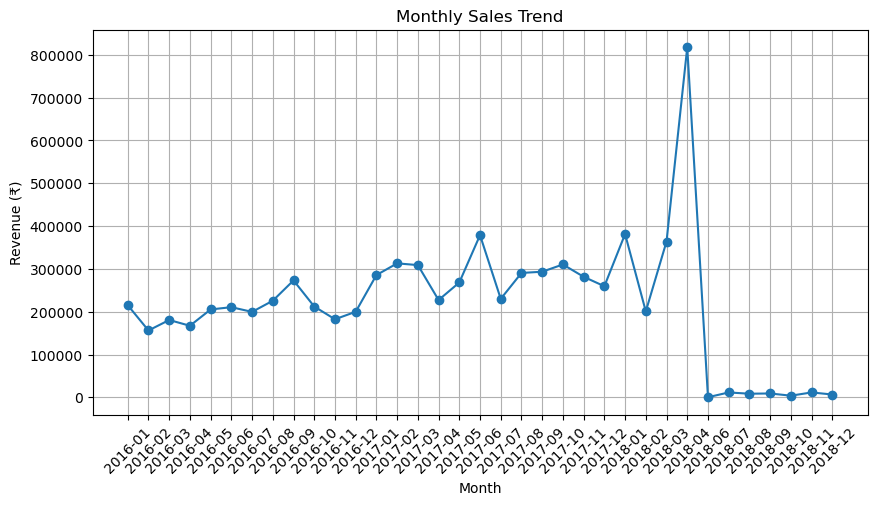

In [16]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["month"].astype(str), monthly_sales["revenue"], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [17]:
store_sales = df.groupby(["store_name", "city_y"])["revenue"].sum().reset_index()
top_stores = store_sales.sort_values("revenue", ascending=False).head(5)

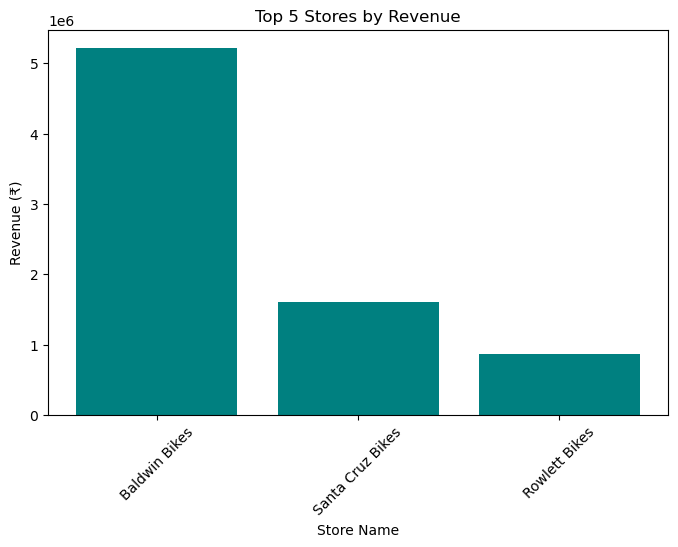

In [18]:
plt.figure(figsize=(8,5))
plt.bar(top_stores["store_name"], top_stores["revenue"], color='teal')
plt.title("Top 5 Stores by Revenue")
plt.xlabel("Store Name")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.show()


In [19]:
customer_metrics = (df.groupby("customer_id")
                      .agg(
                          total_orders=("order_id", "nunique"),
                          total_revenue=("revenue", "sum"),
                          avg_order_value=("revenue", "mean"),
                          last_purchase=("order_date", "max")
                      )
                      .reset_index())




In [20]:
customer_metrics["recency_days"] = (df["order_date"].max() - customer_metrics["last_purchase"]).dt.days
customer_metrics.head()

,customer_id,total_orders,total_revenue,avg_order_value,last_purchase,recency_days
0,1,3,27888.1834,2535.289400,2018-11-18,40
1,2,3,19329.0849,1932.908490,2018-04-09,263
2,3,3,24051.5279,1850.117531,2018-10-21,68
3,4,3,21150.8927,2350.099189,2018-04-18,254
4,5,3,17520.2919,2190.036488,2018-04-17,255


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



X = customer_metrics[["total_orders", "total_revenue", "avg_order_value"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
customer_metrics["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = customer_metrics.groupby("cluster").agg({
    "total_orders": "mean",
    "total_revenue": "mean",
    "avg_order_value": "mean",
    "recency_days": "mean"
}).round(2)


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

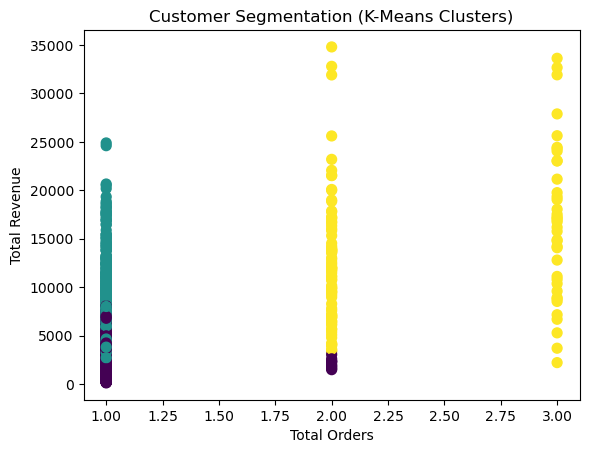

In [25]:
plt.scatter(customer_metrics["total_orders"], customer_metrics["total_revenue"], 
            c=customer_metrics["cluster"], cmap="viridis", s=50)
plt.xlabel("Total Orders")
plt.ylabel("Total Revenue")
plt.title("Customer Segmentation (K-Means Clusters)")
plt.show()

In [26]:
category_sales = df.groupby("category_id")["revenue"].sum().reset_index()
category_sales = category_sales.merge(products[["category_id"]].drop_duplicates(), on="category_id")

category_sales.sort_values("revenue", ascending=False, inplace=True)
print(category_sales.head())




   category_id       revenue
5            6  2.715080e+06
6            7  1.665098e+06
2            3  9.950326e+05
4            5  9.166848e+05
3            4  7.110118e+05


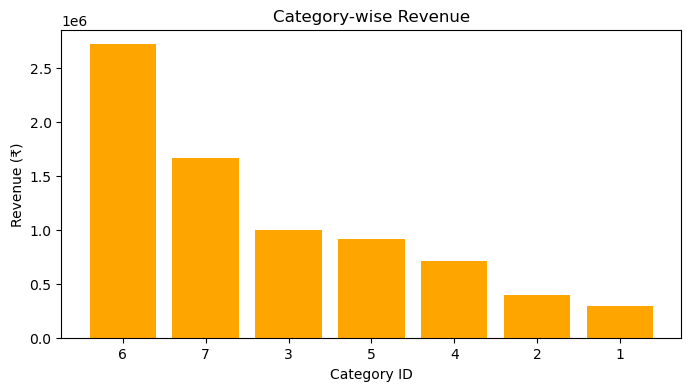

In [27]:

plt.figure(figsize=(8,4))
plt.bar(category_sales["category_id"].astype(str), category_sales["revenue"], color='orange')
plt.title("Category-wise Revenue")
plt.xlabel("Category ID")
plt.ylabel("Revenue (₹)")
plt.show()

In [28]:
final_insights = customer_metrics[[
    "customer_id", "total_orders", "total_revenue",
    "avg_order_value", "recency_days", "cluster"
]]

final_insights["monthly_growth_%"] = monthly_sales["growth_%"].iloc[-1]
final_insights["analysis_date"] = pd.Timestamp.today().normalize()

print(final_insights.head())


   customer_id  total_orders  total_revenue  avg_order_value  recency_days  \
0            1             3     27888.1834      2535.289400            40   
1            2             3     19329.0849      1932.908490           263   
2            3             3     24051.5279      1850.117531            68   
3            4             3     21150.8927      2350.099189           254   
4            5             3     17520.2919      2190.036488           255   

   cluster  monthly_growth_% analysis_date  
0        2        -42.642469    2025-10-14  
1        2        -42.642469    2025-10-14  
2        2        -42.642469    2025-10-14  
3        2        -42.642469    2025-10-14  
4        2        -42.642469    2025-10-14  
